In [1]:
suppressPackageStartupMessages(library("Capybara"))
suppressPackageStartupMessages(library("zellkonverter"))
suppressPackageStartupMessages(library("SingleCellExperiment"))
suppressPackageStartupMessages(library("readr"))
suppressPackageStartupMessages(library("reshape2"))
suppressPackageStartupMessages(library("ggplot2"))

In [2]:
# sessionInfo()

In [3]:
#' Load a SingleCellExperiment object from H5AD and extract key components
#'
#' @param path Path to the .h5ad file.
#' @param assay_name Name of the assay to extract (default: "X").
#'
#' @return A list with the loaded object, counts matrix, and cell metadata.
#'         Elements: obj, counts, obs
load_data <- function(path, assay_name = "X") {
  start_time <- Sys.time()
  cat("==> Loading data from:\n", path, "\n")
  obj <- readH5AD(path)
  cat("✓ Data loaded.\n")

  cat("==> Extracting assay: '", assay_name, "'...\n", sep = "")
  counts <- assay(obj, assay_name)
  cat("✓ Counts matrix: ", nrow(counts), " genes x ", ncol(counts), " cells\n")

  cat("==> Extracting cell metadata (obs)...\n")
  obs <- as.data.frame(colData(obj))
  cat("✓ Metadata: ", nrow(obs), " cells x ", ncol(obs), " fields\n")

  end_time <- Sys.time()
  cat("==> Done. Elapsed time:", round(difftime(end_time, start_time, units = "secs"), 2), "seconds\n")

  return(list(
    obj = obj,
    counts = counts,
    obs = obs
  ))
}


# Load Datasets

In [4]:
# Load reference dataset
ref_path <- "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/basename_ref.h5ad"
ref_data <- load_data(ref_path)
head(ref_data$obs, 5)

==> Loading data from:
 /nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/basename_ref.h5ad 
✓ Data loaded.
==> Extracting assay: 'X'...
✓ Counts matrix:  28538  genes x  8  cells
==> Extracting cell metadata (obs)...
✓ Metadata:  8  cells x  1  fields
==> Done. Elapsed time: 4.6 seconds


,basename
,<fct>
endothelial_cells,endothelial_cells
fibroblasts,fibroblasts
hematopoietic_progenitors,hematopoietic_progenitors
hsc,hsc
innate_lymphoid_cells,innate_lymphoid_cells


In [5]:
# Load our dataset
data_path <- "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad"
data <- load_data(data_path)
head(data$obs, 5)

==> Loading data from:
 /nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad 
✓ Data loaded.
==> Extracting assay: 'X'...
✓ Counts matrix:  21412  genes x  15867  cells
==> Extracting cell metadata (obs)...
✓ Metadata:  15867  cells x  40  fields
==> Done. Elapsed time: 41.63 seconds


,batch,phase,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,⋯,dpt_groups,dpt_order,dpt_order_indices,G1_pseudotime,G1_order,G2M_pseudotime,G2M_order,mean_pseudotime,mean_order,nnz
,<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AAACCCAAGGTTACCT-1,hsc,G1,3679,8.210668,11202,9.323937,27.93251,37.75219,47.49152,60.38207,⋯,0,0,0,0.80452728,0,0.81303751,0,0.8087824,0,3679
AAACCCAAGTTGAAGT-1,hsc,G1,3987,8.291045,10579,9.266721,24.76605,32.86700,40.83562,53.31317,⋯,0,7688,6161,0.91973007,7688,0.92427021,7688,0.9220002,7688,3987
AAACCCAAGTTGTCGT-1,hsc,S,2585,7.857868,6735,8.815222,28.53749,37.37194,48.13660,63.53378,⋯,3,9322,6160,0.47892556,9764,0.04948044,9322,0.2642030,9543,2585
AAACCCACAGAAGCGT-1,hsc,G1,2358,7.765993,5416,8.597297,24.68612,34.78582,45.21787,60.67208,⋯,4,15237,6159,0.08795506,15063,0.50377256,15237,0.2958638,15150,2358
AAACCCACAGGAGGTT-1,hsc,G1,4997,8.516793,21937,9.995976,31.84574,40.55249,50.15271,63.44076,⋯,0,6684,6158,0.79014874,6684,0.78402460,6684,0.7870867,6684,4995


# Handle row names (gene overlap)

In [6]:
cat("Original dimensions:\n")
cat("ref_data$counts:", dim(ref_data$counts), "\n")
cat("data$counts:    ", dim(data$counts), "\n")

common_genes <- intersect(rownames(ref_data$counts), rownames(data$counts))

ref_data$counts <- ref_data$counts[common_genes, , drop = FALSE]
data$counts     <- data$counts[common_genes, , drop = FALSE]

cat("Filtered dimensions (after intersection):\n")
cat("ref_data$counts:", dim(ref_data$counts), "\n")
cat("data$counts:    ", dim(data$counts), "\n")

Original dimensions:
ref_data$counts: 28538 8 
data$counts:     21412 15867 
Filtered dimensions (after intersection):
ref_data$counts: 16609 8 
data$counts:     16609 15867 


# Tissue-Level Classification

In [7]:
?single.round.QP.analysis

single.round.QP.analysis {Capybara},R Documentation
ref,The reference transcriptome taht contains the transcriptome of each potential cell type
sc.data,the transcriptome profile of cells from single-cell RNA-sequencing
scale.bulk.sc,either scale or non-scale. Scaling is recommended to make the reference comparable to the single-cell. Default to scale.
unix.par,"boolean value, either TRUE or FALSE. If using unix/linux based systems, this command can be set to TRUE to parallelize use parallel package. Default to FALSE"
windows.par,"boolean value, either TRUE or FALSE. If using Windows based systems, this command can be set to TRUE to parallelize use snow package. Default to FALSE"
force.eq,either 0 or 1. Setting to 0 assumes the 1st constraint as inequality. Setting to 1 assumes equality. Default to 0
n.cores,"the number of cores to use for parallel processes. If no parallelization selected, no parallelization will be implemented. Only 1 core will be used"
save.to.path,which directory would you like to save your file?
save.to.filename,prefix to the filename to save to. The final filename will be constructed inside of the function by tagging the following string _scale.csv for scaling and _non_scale.csv for not scaling.
bulk.norm,"boolean value, either TRUE or FALSE. Would you like to normalize the reference?"


In [8]:
output_dir <- "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/"
filename <- 'test'
n <- 5000

cat("Sampling", n, "columns from data$count...\n")
start_time_sampling <- Sys.time()

# Sample n column names
sampled.cols <- sample(colnames(data$count), size = n)

# Subset the data frame by sampled columns
sample.data <- data$count[, sampled.cols, drop = FALSE]

end_time_sampling <- Sys.time()
cat("Subset data dimensions: ", dim(sample.data)[1], " rows x ", dim(sample.data)[2], " columns\n")
cat("Sampling and subsetting time: ", round(difftime(end_time_sampling, start_time_sampling, units = "secs"), 2), "seconds\n\n")

cat("Starting single.round.QP.analysis...\n")
start_time_analysis <- Sys.time()

single.round.QP.analysis(
  ref = ref_data$counts,
  sc.data = sample.data,
  scale.bulk.sc = "scale",
  unix.par = TRUE,
  force.eq = 0,
  n.cores = 16,
  save.to.path = output_dir,
  save.to.filename = filename,
  bulk.norm = TRUE,
  norm.sc = TRUE,
  log.bulk = TRUE,
  log.sc = TRUE
)

end_time_analysis <- Sys.time()
cat("QP analysis time: ", round(difftime(end_time_analysis, start_time_analysis, units = "secs"), 2), "seconds\n")


Sampling 5000 columns from data$count...
Subset data dimensions:  16609  rows x  5000  columns
Sampling and subsetting time:  0.26 seconds

Starting single.round.QP.analysis...
QP analysis time:  2225.47 seconds


In [9]:
# With 1 core
# Sampling 5000 columns from data$count...
# Subset data dimensions:  16609  rows x  5000  columns
# Sampling and subsetting time:  0.25 seconds

# Starting single.round.QP.analysis...
# QP analysis time:  2304.82 seconds

In [10]:
filepath <- file.path(output_dir, paste0(filename, "_scale.csv"))
df <- read.csv(filepath, header = TRUE, stringsAsFactors = FALSE)
cat("Rows:", nrow(df), "\nColumns:", ncol(df), "\n")
head(df)

Rows: 5000 
Columns: 11 


,cell_name,frxn_endothelial_cells,frxn_fibroblasts,frxn_hematopoietic_progenitors,frxn_hsc,frxn_innate_lymphoid_cells,frxn_lymphoid_cells,frxn_mesenchymal_cells,frxn_myeloid_cells,Lagrangian,Error
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,TTCACGCTCATTGCCC-1,0.1958154,0.2361731,0.08967559,-1.503880e-18,-1.243221e-18,-4.914707e-19,0.000000e+00,0.20738903,0,2269.313
2,TTGGGCGGTCACGTGC-1,0.1703658,0.2297064,0.03914470,-5.988842e-19,0.000000e+00,-2.168300e-19,1.178661e-01,0.19542737,0,2202.913
3,GGGTAGACAACCAATC-1,0.1158246,0.2142728,0.11375911,1.698126e-02,3.662970e-02,0.000000e+00,7.888400e-02,0.16759295,0,2286.386
4,TGTAGCGCATGACGGC-1,0.1285955,0.2022127,0.25967307,-4.766622e-17,0.000000e+00,-5.641812e-18,1.660625e-01,0.03584892,0,2089.923
5,TCGAAGTGTGCCTTTC-1,0.1479803,0.2686212,0.22731632,8.957789e-18,1.404010e-18,-3.485080e-18,-3.469447e-18,0.12613163,0,2218.923
6,GAAGCGACAAATGGCG-1,0.1500621,0.2700471,0.16991463,-4.277381e-18,-4.324745e-18,-1.327909e-18,0.000000e+00,0.17833056,0,2220.449


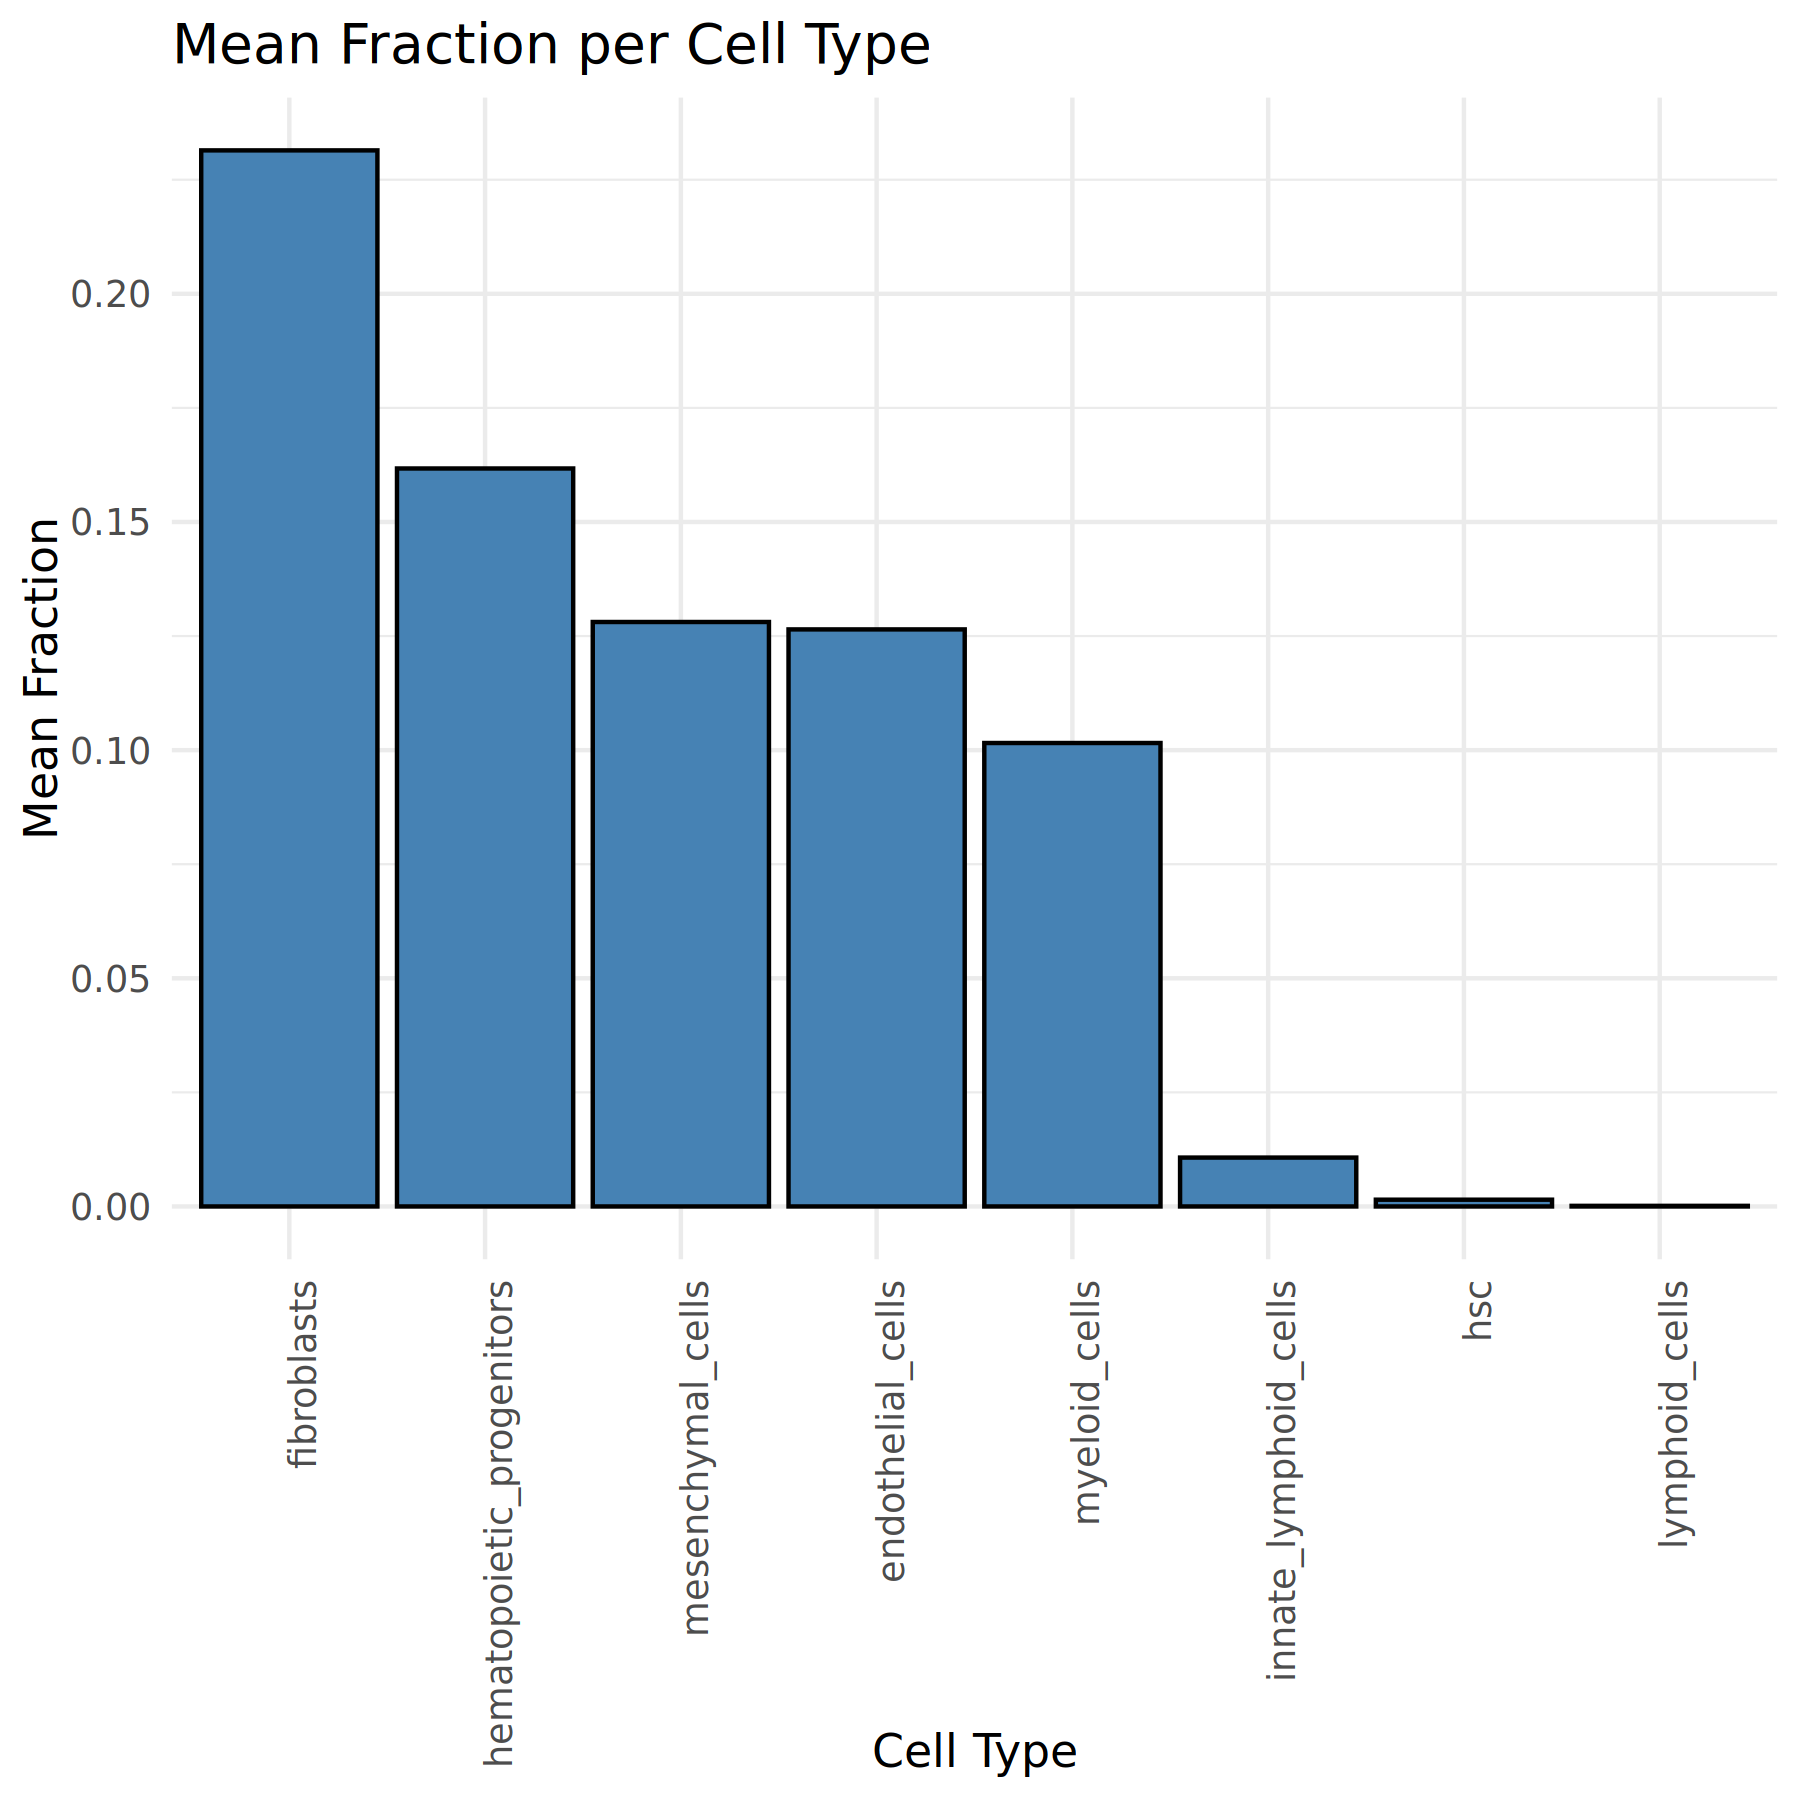

In [11]:
# Select only fraction columns
frac_cols <- grep("^frxn_", names(df), value = TRUE)

# Compute means
mean_fracs <- colMeans(df[frac_cols])

# Convert to data frame
mean_df <- data.frame(
  cell_type = gsub("frxn_", "", names(mean_fracs)),
  mean_fraction = mean_fracs
)


options(repr.plot.width = 6, repr.plot.height = 6, repr.plot.res = 300)
ggplot(mean_df, aes(x = reorder(cell_type, -mean_fraction), y = mean_fraction)) +
  geom_bar(stat = "identity", fill = "steelblue", color = "black") +
  theme_minimal() +
  xlab("Cell Type") +
  ylab("Mean Fraction") +
  ggtitle("Mean Fraction per Cell Type") +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))


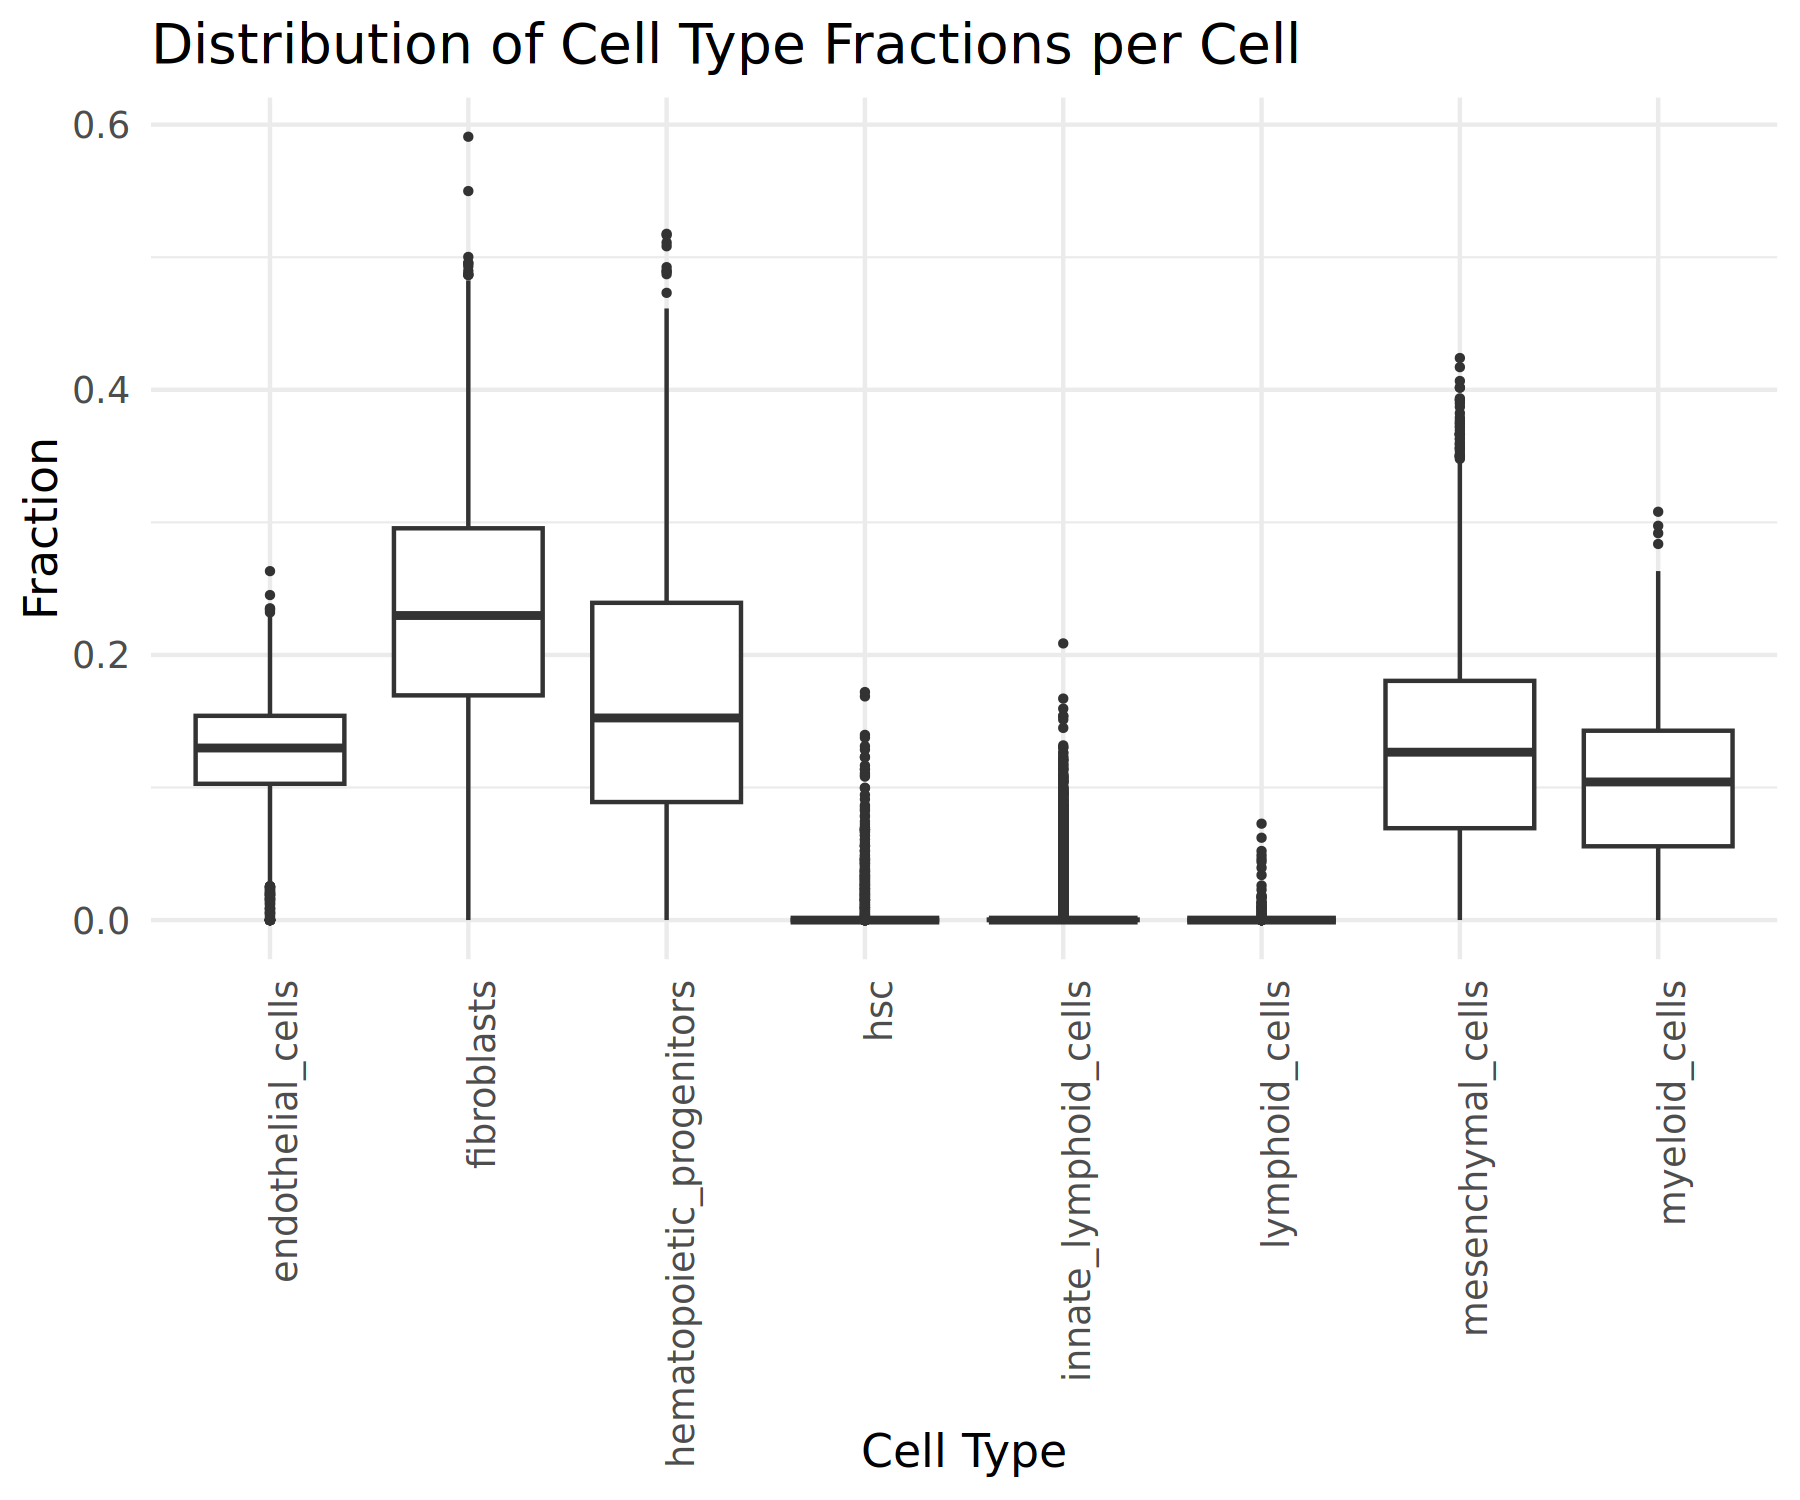

In [12]:
# Melt for long format
options(repr.plot.width = 6, repr.plot.height = 5, repr.plot.res = 300)
long_df <- melt(df, id.vars = "cell_name", measure.vars = frac_cols)

# Boxplot
ggplot(long_df, aes(x = variable, y = value)) +
  geom_boxplot(outlier.size = 0.5) +
  theme_minimal() +
  xlab("Cell Type") +
  ylab("Fraction") +
  ggtitle("Distribution of Cell Type Fractions per Cell") +
  scale_x_discrete(labels = function(x) gsub("frxn_", "", x)) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))


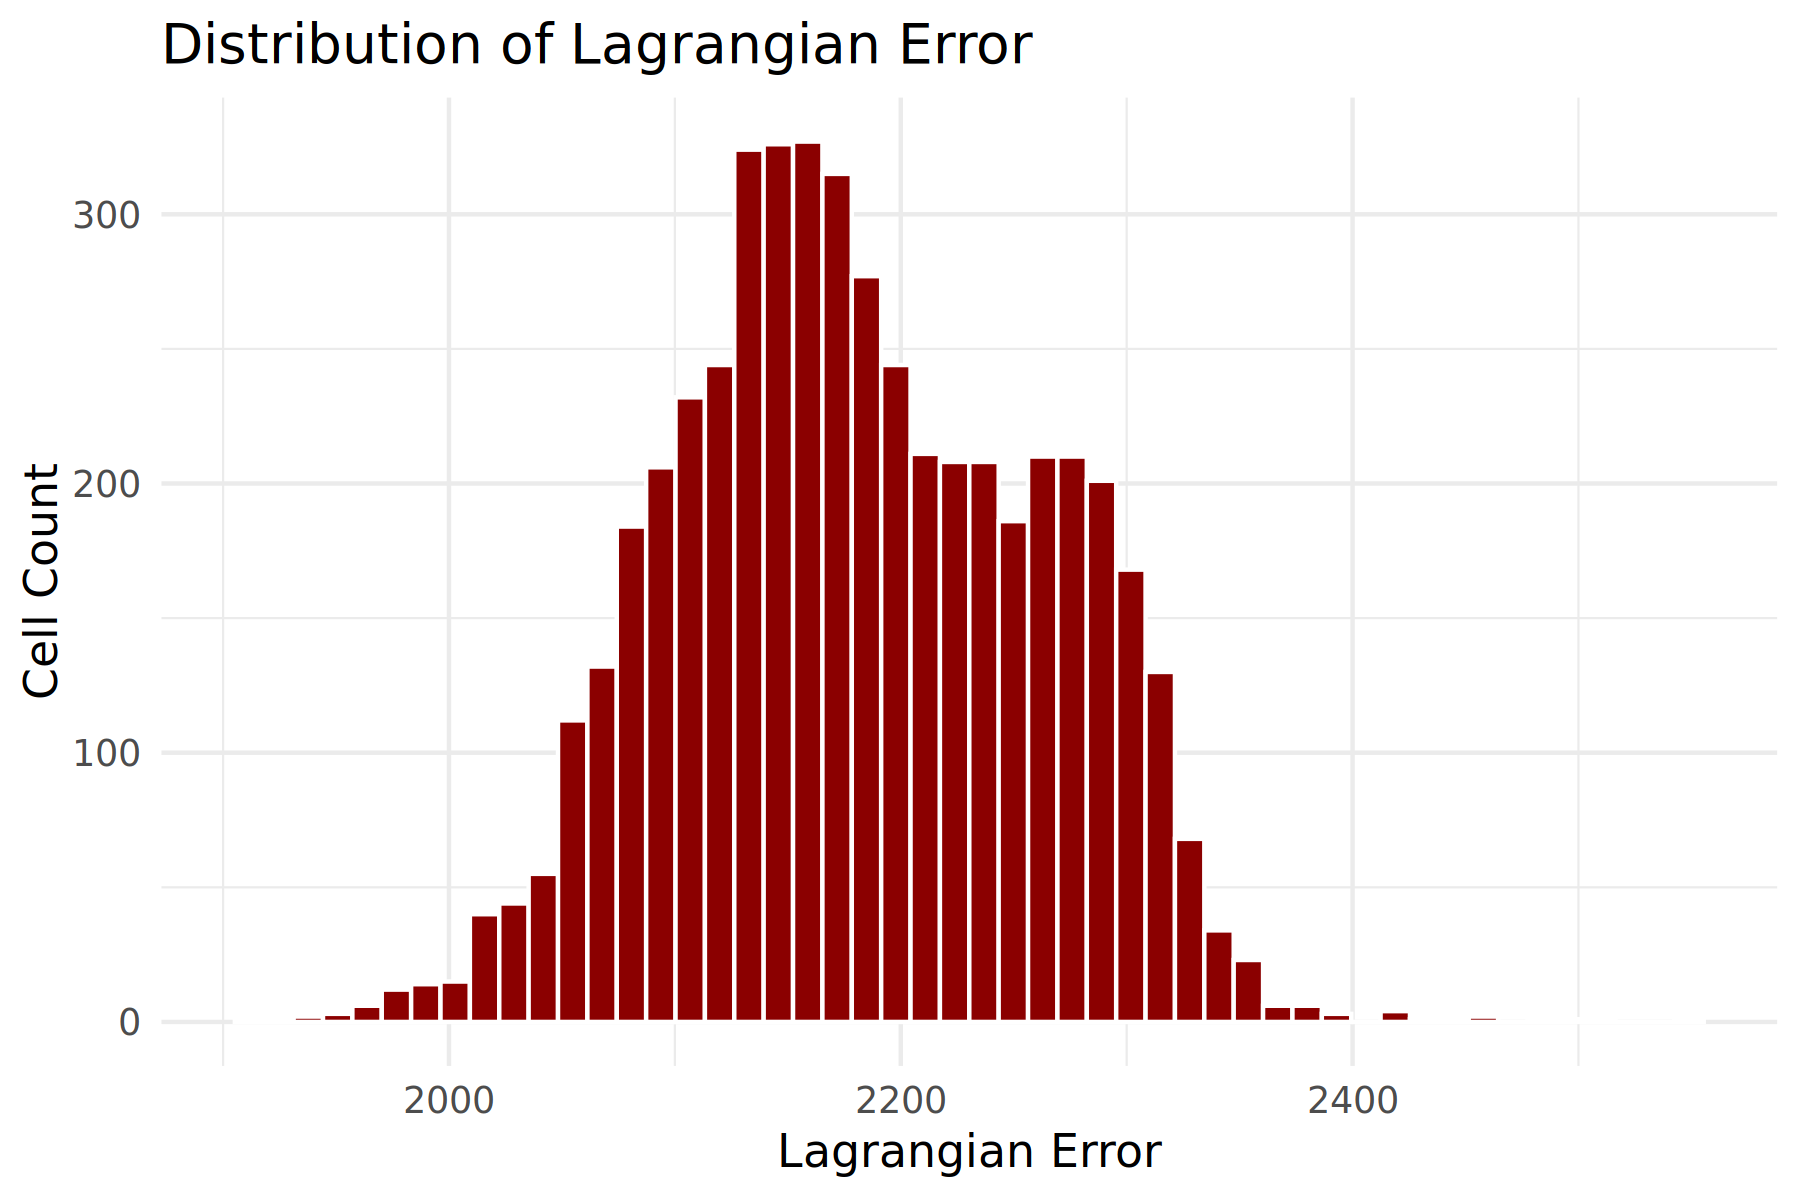

In [13]:
options(repr.plot.width = 6, repr.plot.height = 4, repr.plot.res = 300)
ggplot(df, aes(x = Error)) +
  geom_histogram(bins = 50, fill = "darkred", color = "white") +
  theme_minimal() +
  xlab("Lagrangian Error") +
  ylab("Cell Count") +
  ggtitle("Distribution of Lagrangian Error")


In [14]:
# output_dir <- "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/"
# filename <- 'test'

# n <- 1000

# cat("Sampling", n, "columns from data$count...\n")

# # Sample n column names
# sampled.cols <- sample(colnames(data$count), size = n)

# # Subset the data frame by sampled columns
# sample.data <- data$count[, sampled.cols, drop = FALSE]

# cat("Subset data dimensions: ", dim(sample.data)[1], " rows x ", dim(sample.data)[2], " columns\n")

# single.round.QP.analysis(
#   ref=ref_data$counts,
#   sc.data=sample.data,
#   scale.bulk.sc = "scale",
#   unix.par = TRUE,
#   force.eq = 0,
#   n.cores = 1,
#   save.to.path=output_dir,
#   save.to.filename=filename,
#   bulk.norm = T,
#   norm.sc = T,
#   log.bulk = T,
#   log.sc = T
# )

In [15]:
# ?single.round.QP.analysis

In [16]:
break

ERROR: Error: no loop for break/next, jumping to top level


In [ ]:
# single.round.QP.analysis(
#     bulk.raw, 
#     baron.expr, 
#     scale.bulk.sc = "scale", 
#     unix.par = TRUE, 
#     force.eq = 1, 
#     n.cores = 1,
# )